# Zoom analysis: saved networks at chosen budget points

`cmc.moo_zoom` trained **10 seeds** at each of **5 points** and saved every network:

| point | what it isolates |
|---|---|
| `control` | no budget — structure the tasks alone produce |
| `rate_limited` | cheap firing, dense wiring |
| `middle` | both costs moderately tight |
| `wiring_limited` | sparse wiring, high firing |
| `knee` | best compromise of the budget front |

`rate_limited`, `middle` and `wiring_limited` lie on the same **iso-accuracy curve** of the budget front
(`moo_pareto_analysis.ipynb` §2.2): about equally competent, but a different cost binds. That is the key
contrast for the connectivity analysis.

**Part 1** (this notebook so far): find the NSGA-III front these points were taken from and show where the
zoomed networks — all seeds, not just seed 0 — actually landed on it.

## Setup
`ZOOM_DIR` is the zoom run. The front it came from is found automatically: the zoom points carry the exact
budgets NSGA-III trained with, so the moo run containing a row with those budgets is the source.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from cmc.front import FEASIBLE_MIN_TASK_ACC, compute_front
from cmc.paths import MOO_RUNS_DIR, MOO_ZOOM_RUNS_DIR

ZOOM_DIR = MOO_ZOOM_RUNS_DIR / "dale_core5_5pt_10seed"
OBJ = ("min_task_acc", "metabolic_cost", "wiring_cost")
POINTS = ["control", "rate_limited", "middle", "wiring_limited", "knee"]
COLORS = dict(zip(POINTS, ["#444444", "#1f77b4", "#2ca02c", "#d62728", "#9467bd"]))

zoom = pd.read_csv(ZOOM_DIR / "runs.csv")
zsum = json.loads((ZOOM_DIR / "summary.json").read_text())
budgeted = {p: v for p, v in zsum["points"].items() if v["rate_budget"] is not None}

def find_source_run():
    for run in sorted(MOO_RUNS_DIR.iterdir()):
        csv = run / "runs.csv"
        if not csv.exists() or "rate_budget" not in pd.read_csv(csv, nrows=1).columns:
            continue
        m = pd.read_csv(csv)
        hits = {p: m.index[(m.rate_budget == v["rate_budget"]) & (m.conn_budget == v["conn_budget"])].tolist()
                for p, v in budgeted.items()}
        if all(hits.values()):
            return run, m, {p: h[0] for p, h in hits.items()}
    raise LookupError("no moo run contains all zoom budgets")

SOURCE_DIR, moo, source_rows = find_source_run()
moo["is_feasible"] = moo.min_task_acc >= FEASIBLE_MIN_TASK_ACC
moo["is_pareto"], _ = compute_front(moo.to_dict("records"), OBJ)
print(f"zoom run:   {ZOOM_DIR.name}  ({len(zoom)} networks)")
print(f"source run: {SOURCE_DIR.name}  ({len(moo)} networks, {int(moo.is_pareto.sum())} on the front)")
print("source rows:", source_rows)

zoom run:   dale_core5_5pt_10seed  (50 networks)
source run: dale_core5_nsga3_budget_p24g10  (240 networks, 124 on the front)
source rows: {'rate_limited': 87, 'middle': 39, 'wiring_limited': 38, 'knee': 101}


## Sanity check: does seed 0 reproduce the source network?
Seed 0 at a budget point is trained with the same code, budgets and seed as the NSGA-III network. On CPU
that gives the bit-identical network. On the GPU it does not: CUDA kernels are not deterministic by default
(and the two jobs may have run on different MIG slices), so the result can differ slightly. The question
is whether the difference is small compared with the **seed-to-seed spread** at that point: if it is, the
zoom networks are statistically the networks we chose, just not the same bits.

In [2]:
rows = []
for p, i in source_rows.items():
    z0 = zoom[(zoom.point == p) & (zoom.seed == 0)].iloc[0]
    sd = zoom[zoom.point == p].min_task_acc.std()
    d_acc = z0.min_task_acc - moo.loc[i, "min_task_acc"]
    rows.append({
        "point": p,
        "acc (moo)": moo.loc[i, "min_task_acc"], "acc (zoom seed 0)": z0.min_task_acc,
        "Δacc": d_acc, "seed std": sd, "|Δacc| / std": abs(d_acc) / sd,
        "Δmetabolic %": 100 * (z0.metabolic_cost / moo.loc[i, "metabolic_cost"] - 1),
        "Δwiring %": 100 * (z0.wiring_cost / moo.loc[i, "wiring_cost"] - 1),
        "bit-identical": bool(all(moo.loc[i, c] == z0[c] for c in ["min_task_acc", "metabolic_cost", "wiring_cost", "conn_frac"])),
    })
check = pd.DataFrame(rows).set_index("point")
display(check.round(4))
print("all within 1 seed std:", bool((check["|Δacc| / std"] < 1).all()))

,acc (moo),acc (zoom seed 0),Δacc,seed std,|Δacc| / std,Δmetabolic %,Δwiring %,bit-identical
point,,,,,,,,
rate_limited,0.6609,0.6609,0.0000,0.0857,0.0000,0.0000,0.0,True
middle,0.6672,0.6859,0.0187,0.0701,0.2673,-0.2395,0.0,False
wiring_limited,0.6547,0.6484,-0.0062,0.0452,0.1382,-0.0115,-0.0,False
knee,0.7203,0.7141,-0.0062,0.0455,0.1373,0.3111,-0.0,False


all within 1 seed std: True


## Per-point summary across seeds
The front was built from **one seed per budget**. The zoom shows the spread a budget really produces:
accuracy varies between seeds, while the costs are pinned by the budgets (wiring exactly, metabolic up to
the ~1.1x eval factor).

In [3]:
agg = zoom.groupby("point").agg(
    n=("seed", "size"), n_feasible=("is_feasible", "sum"),
    acc_mean=("min_task_acc", "mean"), acc_std=("min_task_acc", "std"),
    acc_min=("min_task_acc", "min"), acc_max=("min_task_acc", "max"),
    metabolic=("metabolic_cost", "mean"), wiring=("wiring_cost", "mean"),
    conn_frac=("conn_frac", "mean"), lambda_rate=("final_lambda_rate", "mean"),
).reindex(POINTS)
agg["acc_seed0_moo"] = [moo.loc[source_rows[p], "min_task_acc"] if p in source_rows else np.nan for p in POINTS]
display(agg.round(4))

,n,n_feasible,acc_mean,acc_std,acc_min,acc_max,metabolic,wiring,conn_frac,lambda_rate,acc_seed0_moo
point,,,,,,,,,,,
control,10,10,0.8728,0.0247,0.8469,0.9219,0.9627,0.0267,0.7563,0.0000,NaN
rate_limited,10,7,0.6627,0.0857,0.5312,0.7688,0.0025,0.0228,0.6366,1.0832,0.6609
middle,10,10,0.7306,0.0701,0.6047,0.8047,0.0068,0.0083,0.2342,0.2421,0.6672
wiring_limited,10,10,0.6786,0.0452,0.6141,0.7469,0.0353,0.0027,0.0624,0.0026,0.6547
knee,10,10,0.7466,0.0455,0.6750,0.8375,0.0222,0.0045,0.1165,0.0193,0.7203


## The zoom points on the source front (3D, interactive)

Background, as in `moo_pareto_analysis.ipynb`: networks that fail a task (grey ×), dominated (silver), the
front (small, light). Orange plane: acceptable accuracy (`min_task_acc = 0.6`).
Foreground, one colour per zoom point: **every seed** (small dots; × = fails a task) and the **seed mean**
(large diamond). Hover for seed, accuracy and costs. `control` has no budget, so it sits far to the right
(unconstrained firing ~0.96) — it is the reference, not a front point.

In [4]:
def xyz(sub):
    return dict(x=np.log10(sub.metabolic_cost), y=np.log10(sub.wiring_cost), z=sub.min_task_acc)

def hov(sub, label):
    seed = lambda r: f" seed {r.seed}" if hasattr(r, "point") else ""
    return [f"{label}{seed(r)}<br>min_task_acc={r.min_task_acc:.3f}<br>metabolic={r.metabolic_cost:.4f}  "
            f"wiring={r.wiring_cost:.4f}  conn_frac={r.conn_frac:.3f}" for r in sub.itertuples()]

bad, dom, fr = moo[~moo.is_feasible], moo[moo.is_feasible & ~moo.is_pareto], moo[moo.is_pareto]
traces = [
    go.Scatter3d(**xyz(bad), mode="markers", name="moo: fails a task", marker=dict(size=2, color="lightgrey", symbol="x"), hoverinfo="skip"),
    go.Scatter3d(**xyz(dom), mode="markers", name="moo: dominated", marker=dict(size=2, color="silver", opacity=0.5), hoverinfo="skip"),
    go.Scatter3d(**xyz(fr), mode="markers", name=f"moo front ({len(fr)})", marker=dict(size=3, color="#9ecae1", opacity=0.7),
                 hovertext=hov(fr, "moo front"), hoverinfo="text"),
]
for p in POINTS:
    sub = zoom[zoom.point == p]
    for feas_, sym in ((True, "circle"), (False, "x")):
        s = sub[sub.is_feasible == feas_]
        if len(s):
            traces.append(go.Scatter3d(**xyz(s), mode="markers", legendgroup=p, showlegend=False,
                                       marker=dict(size=4, color=COLORS[p], symbol=sym, opacity=0.8),
                                       hovertext=hov(s, p), hoverinfo="text"))
    m = sub[["metabolic_cost", "wiring_cost", "min_task_acc"]].mean()
    traces.append(go.Scatter3d(x=[np.log10(m.metabolic_cost)], y=[np.log10(m.wiring_cost)], z=[m.min_task_acc],
                               mode="markers", name=f"{p} ({int(sub.is_feasible.sum())}/{len(sub)} feasible)", legendgroup=p,
                               marker=dict(size=9, color=COLORS[p], symbol="diamond", line=dict(color="black", width=1)),
                               hovertext=[f"{p} mean of {len(sub)} seeds<br>min_task_acc={m.min_task_acc:.3f} ± {sub.min_task_acc.std():.3f}"],
                               hoverinfo="text"))

allx = np.log10(pd.concat([moo.metabolic_cost, zoom.metabolic_cost]))
ally = np.log10(pd.concat([moo.wiring_cost, zoom.wiring_cost]))
pad = lambda v: (v.min() - 0.05 * (v.max() - v.min()), v.max() + 0.05 * (v.max() - v.min()))
(x0, x1), (y0, y1) = pad(allx), pad(ally)
traces.append(go.Surface(x=[x0, x1], y=[y0, y1], z=[[FEASIBLE_MIN_TASK_ACC] * 2] * 2,
                         colorscale=[[0, "orange"], [1, "orange"]], opacity=0.2, showscale=False,
                         name=f"acceptable: min_task_acc = {FEASIBLE_MIN_TASK_ACC}", showlegend=True, hoverinfo="skip"))
fig = go.Figure(traces)
fig.update_layout(title=f"Zoom points on the budget front — {SOURCE_DIR.name}",
                  scene=dict(xaxis_title="log10(metabolic cost)", yaxis_title="log10(wiring cost)",
                             zaxis_title="min_task_acc", aspectmode="cube"),
                  width=980, height=740, legend=dict(x=0.0, y=1.0))
fig.show()

## The same, as static 2D projections
For figures and quick reading. Light blue: the moo front. Coloured: every seed of each zoom point, mean as
a large diamond with ±1 std error bars on accuracy.

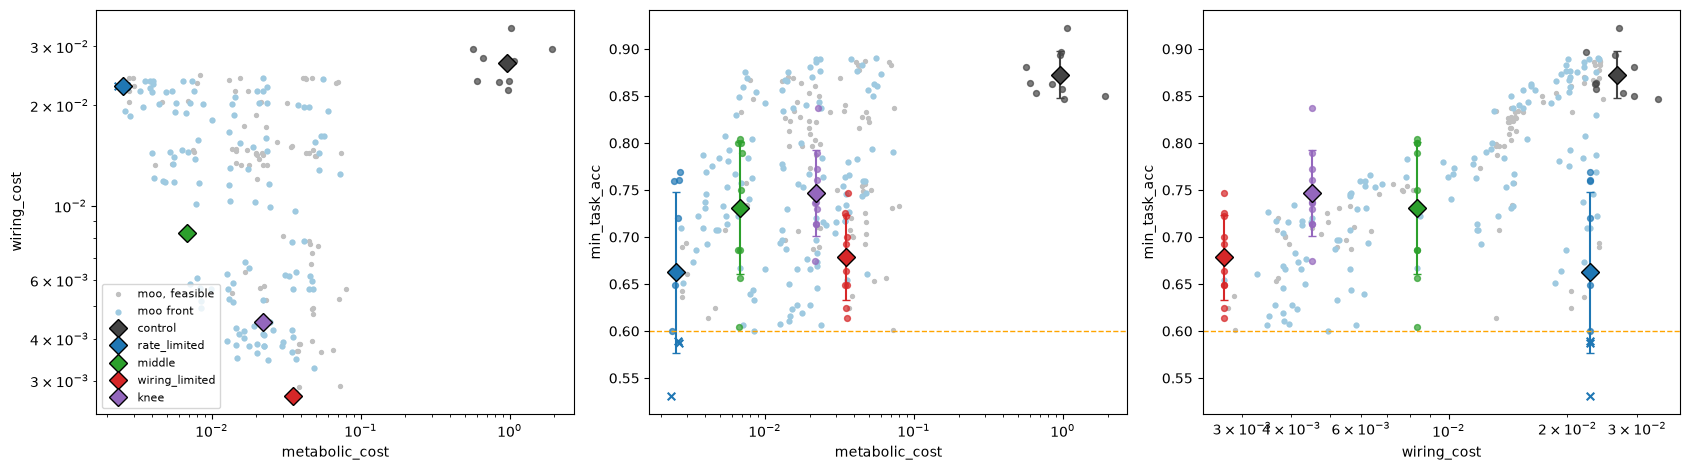

In [5]:
pairs = [("metabolic_cost", "wiring_cost"), ("metabolic_cost", "min_task_acc"), ("wiring_cost", "min_task_acc")]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, (x, y) in zip(axes, pairs):
    ax.scatter(moo[moo.is_feasible][x], moo[moo.is_feasible][y], s=8, c="silver", label="moo, feasible")
    ax.scatter(fr[x], fr[y], s=12, c="#9ecae1", label="moo front")
    for p in POINTS:
        sub = zoom[zoom.point == p]
        ok = sub.is_feasible
        ax.scatter(sub[ok][x], sub[ok][y], s=18, color=COLORS[p], alpha=0.7)
        ax.scatter(sub[~ok][x], sub[~ok][y], s=30, color=COLORS[p], marker="x")
        yerr = sub[y].std() if y == "min_task_acc" else None
        ax.errorbar(sub[x].mean(), sub[y].mean(), yerr=yerr, fmt="D", ms=9, color=COLORS[p],
                    mec="k", capsize=3, label=p)
    if y == "min_task_acc":
        ax.axhline(FEASIBLE_MIN_TASK_ACC, color="orange", ls="--", lw=1)
    ax.set_xscale("log")
    if y != "min_task_acc":
        ax.set_yscale("log")
    ax.set_xlabel(x); ax.set_ylabel(y)
axes[0].legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

# Part 2 — how are the networks wired?

Two basic views, per point:

1. **Task variance** (Yang et al. 2019): which tasks drive each neuron, and do neurons fall into functional
   clusters? This gives each neuron a functional identity.
2. **The recurrent weight matrix `W_rec`**, ordered E first then I, and within each population by functional
   cluster — so block structure (who connects to whom) becomes visible.

Then a quantitative summary across all seeds: connection strength and density per E/I block, and E/I balance.

Conventions: the network computes `h @ W`, so `W[i, j]` is the synapse **from i to j**. Plots show `W.T`:
**rows = postsynaptic (to), columns = presynaptic (from)**. The first `n_e` neurons are excitatory, the rest inhibitory
(`frac_e = 0.8`); E columns are positive, I columns negative (Dale's law).

In [6]:
import contextlib, io
import torch
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from cmc.train_cog import load_checkpoint, connection_fraction

TASKS = zsum["active_tasks"]

def load(point, seed):
    with contextlib.redirect_stdout(io.StringIO()):
        model, config, ck = load_checkpoint(ZOOM_DIR / point / f"seed_{seed:02d}.pt")
    W = model.effective_w_rec().detach().numpy()          # W[pre, post]
    return model, ck, W

# A representative seed per point: the feasible seed with median accuracy.
def representative_seed(point):
    sub = zoom[(zoom.point == point) & zoom.is_feasible].sort_values("min_task_acc")
    return int(sub.iloc[len(sub) // 2].seed)

REP = {p: representative_seed(p) for p in POINTS}
N_E = int(load(POINTS[0], 0)[0].n_e)                   # E neurons come first
print("representative seeds:", REP)

representative seeds: {'control': 0, 'rate_limited': 3, 'middle': 8, 'wiring_limited': 1, 'knee': 8}


## 2.1 Task variance (Yang et al. 2019)

For each neuron and task: the variance of its activity **across trials**, at each time step after fixation
onset, averaged over time (`cmc.runner.activity_summary`, saved in every checkpoint). A neuron with high
task variance for a task carries information about that task's trials.

* **Normalised task variance**: each neuron's vector divided by its maximum over tasks, so a neuron is
  described by *which* tasks drive it, not how strongly.
* **Active neurons**: summed task variance above 1% of the network's maximum. A relative threshold, because
  the absolute scale differs ~30x between points (the rate budget shrinks all activity); Yang's absolute
  cut-off would mean something different at each point.
* **Clusters**: k-means on the normalised vectors of active neurons, k chosen by silhouette score (k = 2-10),
  as in Yang et al.

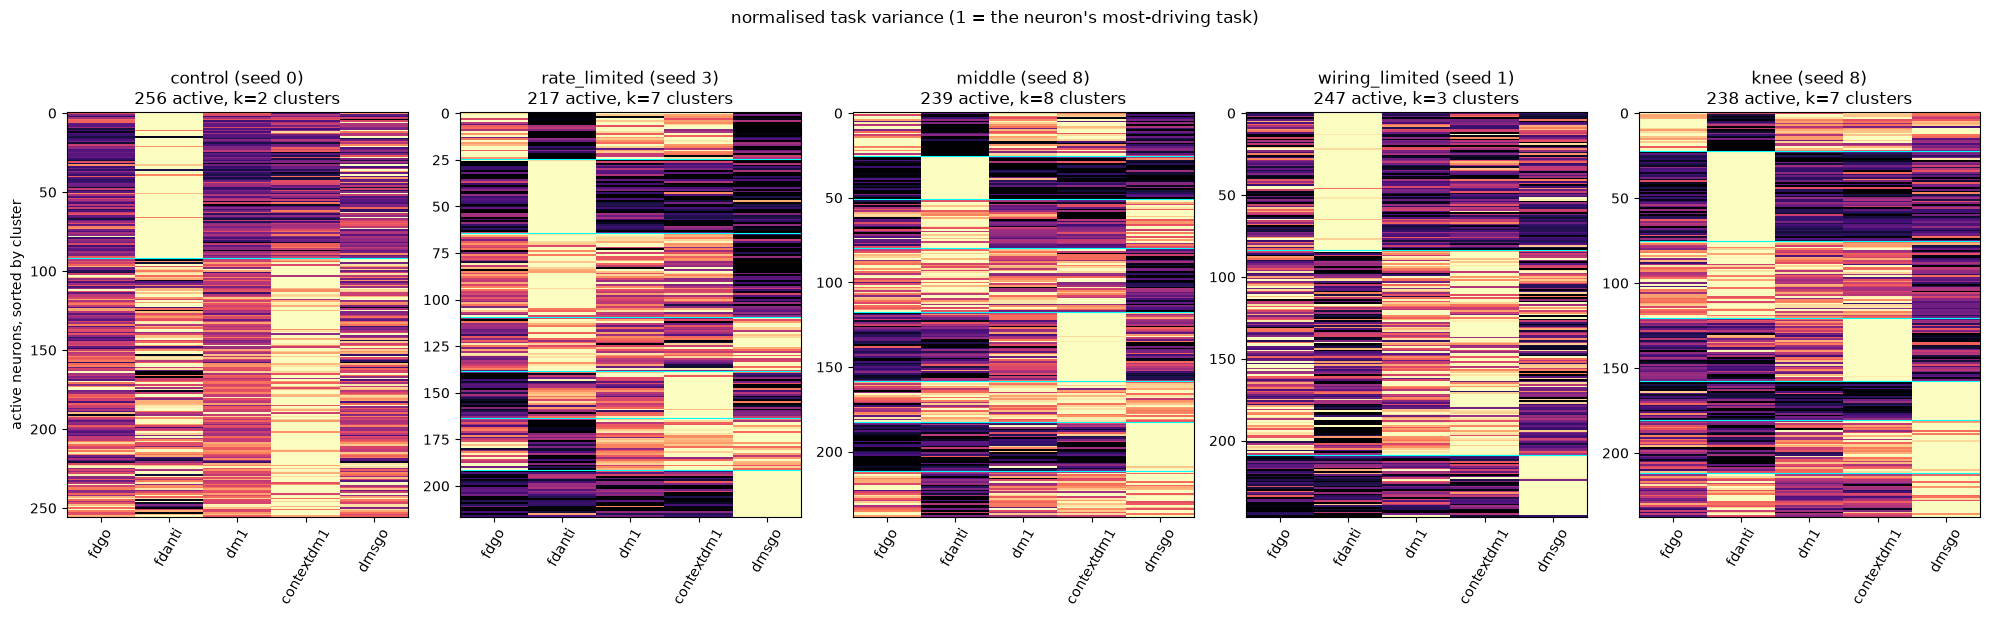

In [7]:
def tv_clusters(tv, k_range=range(2, 11), seed=0):
    total = tv.sum(axis=0)
    active = total > 1e-2 * total.max()
    norm = tv[:, active] / tv[:, active].max(axis=0, keepdims=True)
    X = norm.T
    best = (None, -1, None)
    for k in k_range:
        if k >= len(X):
            break
        lab = KMeans(n_clusters=k, n_init=10, random_state=seed).fit_predict(X)
        sc = silhouette_score(X, lab)
        if sc > best[1]:
            best = (k, sc, lab)
    k, sc, lab = best
    labels = np.full(tv.shape[1], -1)
    labels[active] = lab
    # Relabel clusters in order of their preferred task, so plots are comparable across networks.
    pref = {c: np.argmax(norm[:, lab == c].mean(axis=1)) for c in range(k)}
    order = sorted(range(k), key=lambda c: (pref[c], -norm[pref[c], lab == c].mean()))
    remap = {c: i for i, c in enumerate(order)}
    labels[active] = [remap[c] for c in lab]
    return dict(active=active, norm_full=tv / np.maximum(tv.max(axis=0, keepdims=True), 1e-30),
                labels=labels, k=k, silhouette=sc)

fig, axes = plt.subplots(1, len(POINTS), figsize=(4 * len(POINTS), 6), sharey=False)
cl_rep = {}
for ax, p in zip(axes, POINTS):
    _, ck, _ = load(p, REP[p])
    cl = tv_clusters(ck["task_variance"])
    cl_rep[p] = cl
    idx = np.flatnonzero(cl["active"])
    idx = idx[np.lexsort((idx >= N_E, cl["labels"][idx]))]       # by cluster, E before I inside
    ax.imshow(cl["norm_full"][:, idx].T, aspect="auto", cmap="magma", vmin=0, vmax=1, interpolation="nearest")
    for b in np.flatnonzero(np.diff(cl["labels"][idx])) + 0.5:
        ax.axhline(b, color="cyan", lw=0.8)
    ax.set_xticks(range(len(TASKS))); ax.set_xticklabels(TASKS, rotation=60)
    ax.set_title(f"{p} (seed {REP[p]})\n{cl['active'].sum()} active, k={cl['k']} clusters")
axes[0].set_ylabel("active neurons, sorted by cluster")
plt.suptitle("normalised task variance (1 = the neuron's most-driving task)", y=1.02)
plt.tight_layout(); plt.show()

Across **all seeds**: how many neurons are active, how many clusters, and how cleanly they separate
(silhouette). Plus, per task, the fraction of active neurons that task drives most — does a constraint
shift the population toward or away from particular tasks (e.g. the bottleneck, dmsgo)?

n_active        n_active_E        n_active_I          k        \
                   mean    std       mean    std       mean   std mean   std   
point                                                                          
control           254.7   1.89      203.5   0.97       51.2  1.03  2.3  0.95   
rate_limited      203.9  16.73      154.5  15.88       49.4  1.43  4.8  2.15   
middle            221.1  13.62      172.4  12.03       48.7  2.26  5.6  3.03   
wiring_limited    230.1   9.18      179.6   8.96       50.5  1.18  4.2  1.87   
knee              239.8   8.05      189.1   7.50       50.7  1.42  4.8  1.48   

               silhouette        
                     mean   std  
point                            
control              0.32  0.02  
rate_limited         0.33  0.02  
middle               0.31  0.02  
wiring_limited       0.33  0.02  
knee                 0.31  0.02

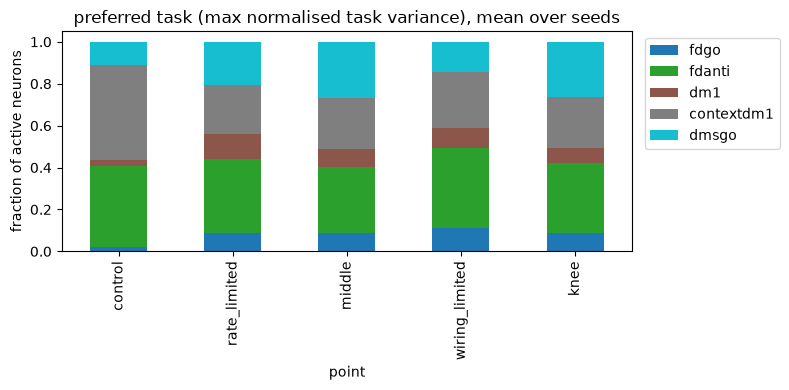

In [8]:
rows, pref_rows = [], []
for p in POINTS:
    for seed in sorted(zoom[zoom.point == p].seed):
        _, ck, _ = load(p, seed)
        cl = tv_clusters(ck["task_variance"])
        n_act = int(cl["active"].sum())
        rows.append({"point": p, "seed": seed, "n_active": n_act,
                     "n_active_E": int(cl["active"][:N_E].sum()), "n_active_I": int(cl["active"][N_E:].sum()),
                     "k": cl["k"], "silhouette": cl["silhouette"]})
        prefs = np.argmax(cl["norm_full"][:, cl["active"]], axis=0)
        pref_rows.append({"point": p, "seed": seed, **{t: float(np.mean(prefs == i)) for i, t in enumerate(TASKS)}})
tvstats = pd.DataFrame(rows)
display(tvstats.groupby("point")[["n_active", "n_active_E", "n_active_I", "k", "silhouette"]].agg(["mean", "std"]).reindex(POINTS).round(2))

prefs = pd.DataFrame(pref_rows).groupby("point")[TASKS].mean().reindex(POINTS)
ax = prefs.plot.bar(stacked=True, figsize=(8, 4), colormap="tab10")
ax.set_ylabel("fraction of active neurons"); ax.set_title("preferred task (max normalised task variance), mean over seeds")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left"); plt.tight_layout(); plt.show()

> **What we see (2.1).**
>
> * **Constraints make neurons more specialised.** Control networks split into only ~2 clusters (mean 2.3)
>   and most neurons respond to several tasks. Every constrained point splits into ~4-6 clusters, each
>   dominated by one task (the bright single-task columns in the heatmaps). The clearest new group is a
>   **dmsgo-specific cluster**, which the control does not have.
> * **More of the population works on the memory task.** The share of neurons whose strongest task is dmsgo
>   rises from ~11% (control) to 14-27% (constrained), while contextdm1's share falls from ~45% to ~25%.
>   Under a budget the network moves resources to the task that limits its performance.
> * **Caveat:** silhouette scores are ~0.31-0.33 at every point, so the clusters are real but soft: overlapping
>   groups rather than cleanly separated cell types. The k values vary between seeds (std 1-3).

## 2.2 The recurrent weight matrix, E/I ordered

Representative seed per point. Order: E neurons, then I (white lines); inside each population, by
functional cluster from 2.1 (inactive neurons last). Colour: signed weight, red = excitatory, blue =
inhibitory, clipped at the 99th percentile of |w| of that network so the structure is visible (the scale
differs strongly between points; see the colour bars).

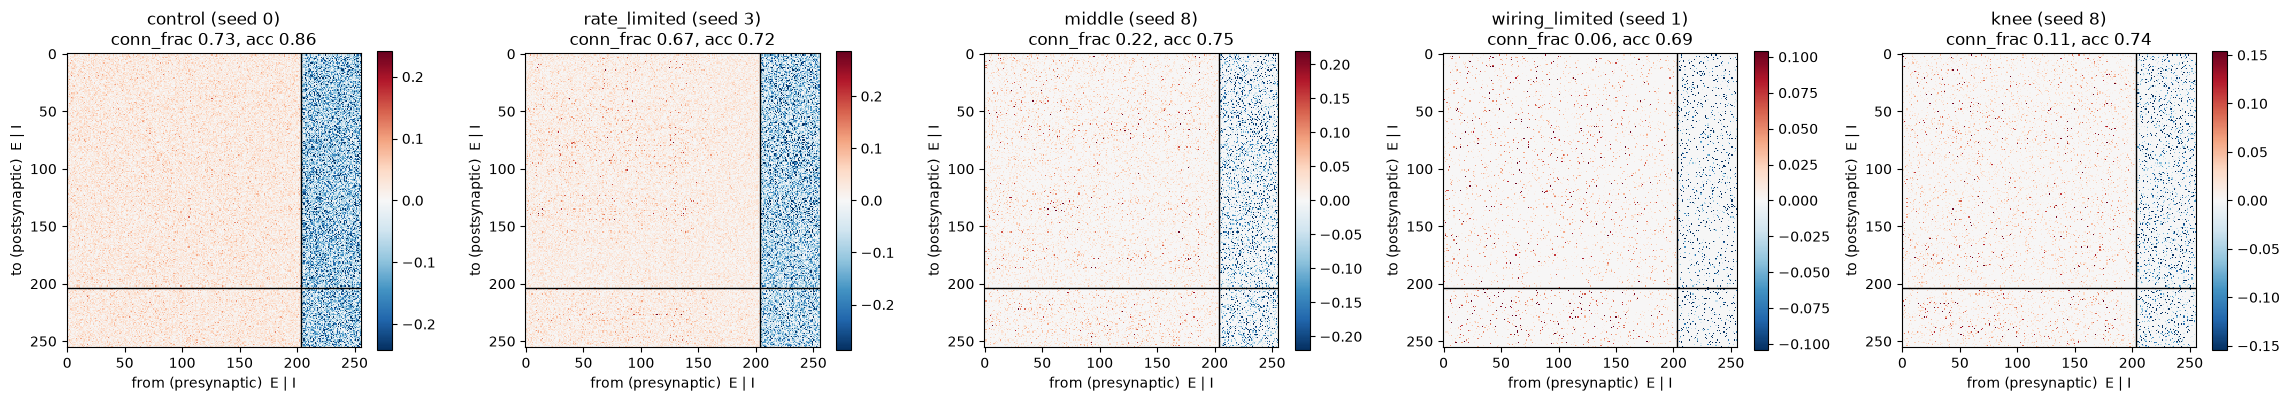

In [9]:
def ei_cluster_order(cl):
    lab = np.where(cl["labels"] < 0, 999, cl["labels"])
    idx = np.arange(len(lab))
    return idx[np.lexsort((lab, idx >= N_E))]

fig, axes = plt.subplots(1, len(POINTS), figsize=(4.6 * len(POINTS), 4.6))
for ax, p in zip(axes, POINTS):
    _, ck, W = load(p, REP[p])
    o = ei_cluster_order(cl_rep[p])
    M = W[np.ix_(o, o)].T                                     # rows = post, cols = pre
    v = np.percentile(np.abs(M[M != 0]), 99)
    im = ax.imshow(M, cmap="RdBu_r", vmin=-v, vmax=v, interpolation="nearest")
    for b in [N_E - 0.5]:
        ax.axhline(b, color="k", lw=1); ax.axvline(b, color="k", lw=1)
    row = zoom[(zoom.point == p) & (zoom.seed == REP[p])].iloc[0]
    ax.set_title(f"{p} (seed {REP[p]})\nconn_frac {row.conn_frac:.2f}, acc {row.min_task_acc:.2f}")
    ax.set_xlabel("from (presynaptic)  E | I"); ax.set_ylabel("to (postsynaptic)  E | I")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

> **What we see (2.2).** No block structure is visible, even with neurons ordered E/I and then by
> functional cluster: the matrices look like salt-and-pepper at every point. The obvious differences are
> scale and sparsity, not organisation. Whether same-cluster neurons connect *more than chance* is a
> quantitative question the eye cannot answer at this density (see "next steps").

A closer look at the sparsest network (`wiring_limited`, ~6% of connections left): which connections
survive? Present = E/I-normalised magnitude above 0.01, the same rule as `conn_frac`.

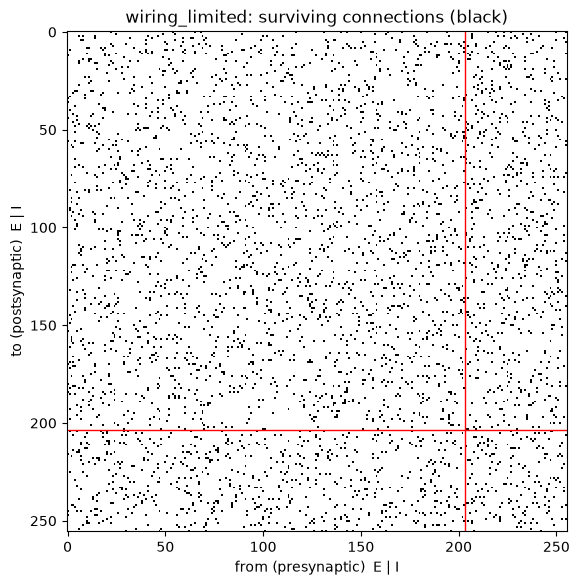

In [10]:
p = "wiring_limited"
model, ck, W = load(p, REP[p])
o = ei_cluster_order(cl_rep[p])
mag = (np.abs(W) / model.ei_row_scale().numpy()[:, None])[np.ix_(o, o)].T
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.imshow(mag > 1e-2, cmap="Greys", interpolation="nearest")
ax.axhline(N_E - 0.5, color="r", lw=1); ax.axvline(N_E - 0.5, color="r", lw=1)
ax.set_xlabel("from (presynaptic)  E | I"); ax.set_ylabel("to (postsynaptic)  E | I")
ax.set_title(f"{p}: surviving connections (black)")
plt.show()

## 2.3 E/I blocks across all seeds

Per network and block (E→E, E→I, I→E, I→I):
* **density**: fraction of possible synapses present (E/I-normalised magnitude > 0.01, as `conn_frac`);
* **mean strength**: mean |w| over *present* synapses (raw, not normalised: I synapses start ~3.9x larger
  by construction).

Bars: mean over the feasible seeds, error bars: std. A cortical-like answer would be sparse, specific
excitation and denser inhibition onto excitatory cells (I→E).

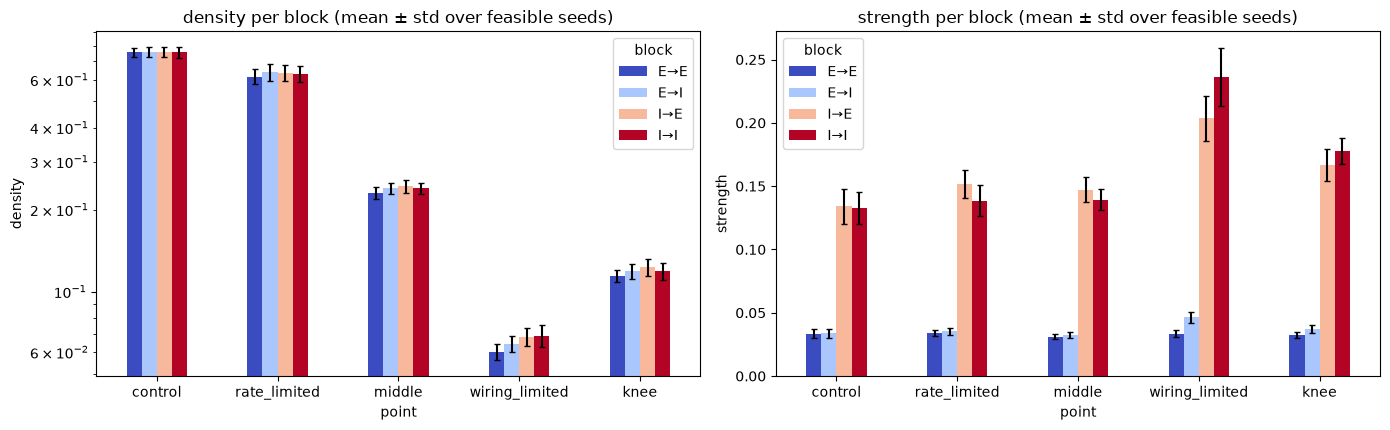

block,E→E,E→I,I→E,I→I
point,,,,
control,0.756,0.758,0.757,0.755
rate_limited,0.616,0.637,0.637,0.631
middle,0.230,0.239,0.243,0.239
wiring_limited,0.060,0.064,0.068,0.069
knee,0.114,0.119,0.123,0.119


In [11]:
BLOCKS = {"E→E": (slice(0, N_E), slice(0, N_E)), "E→I": (slice(0, N_E), slice(N_E, None)),
          "I→E": (slice(N_E, None), slice(0, N_E)), "I→I": (slice(N_E, None), slice(N_E, None))}
rows = []
for p in POINTS:
    for seed in sorted(zoom[(zoom.point == p) & zoom.is_feasible].seed):
        model, ck, W = load(p, seed)
        mag = np.abs(W) / model.ei_row_scale().numpy()[:, None]
        mask = model.no_autapse.numpy() > 0
        for b, (pre, post) in BLOCKS.items():
            present = (mag[pre, post] > 1e-2) & mask[pre, post]
            vals = np.abs(W[pre, post])[present]
            rows.append({"point": p, "seed": seed, "block": b,
                         "density": present.sum() / mask[pre, post].sum(),
                         "strength": vals.mean() if len(vals) else 0.0})
blocks = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
for ax, metric in zip(axes, ["density", "strength"]):
    piv = blocks.groupby(["point", "block"])[metric].agg(["mean", "std"]).unstack("block").reindex(POINTS)
    piv["mean"].plot.bar(yerr=piv["std"], ax=ax, capsize=2, colormap="coolwarm", rot=0)
    ax.set_title(f"{metric} per block (mean ± std over feasible seeds)"); ax.set_ylabel(metric)
axes[0].set_yscale("log")
plt.tight_layout(); plt.show()
display(blocks.groupby(["point", "block"]).density.mean().unstack().reindex(POINTS).round(3))

> **What we see (2.3).**
>
> * **Density: pruning hits all four blocks about equally** (within ~10% at every point). This is largely
>   **built into the method**: the wiring budget is enforced by soft-thresholding every synapse by the same
>   E/I-normalised amount, so which *class* of synapse survives is not something the network chose here.
>   Treat block densities as a description of the projection, not as a learned motif.
> * **Strength: inhibition gets stronger as wiring tightens.** The surviving I→E and I→I synapses grow from
>   ~0.13 (control) to 0.20-0.24 (wiring_limited), while excitatory synapses stay at ~0.033 at every point.
>   This *is* learned: the network keeps fewer inhibitory synapses but makes each one count more.

## 2.4 E/I balance

Every neuron receives recurrent input from excitatory neurons (positive weights) and from inhibitory
neurons (negative weights). Two simple numbers per neuron `j`:

* **total excitatory input** `E_j = Σ_i W[i, j]` over the E neurons `i` (all positive),
* **total inhibitory input** `I_j = Σ_i |W[i, j]|` over the I neurons `i`.

These are *column sums* of `W` (column `j` = everything that arrives at neuron `j`). They measure the
**wiring** onto a neuron: how much excitation and inhibition it could receive if all its inputs fired at
the same rate.

**What the input ratio means.** `I_j / E_j` compares the two. A ratio of 1 means inhibition and excitation
onto that neuron are equal in total weight, so they cancel and the net recurrent drive is small. Above 1,
inhibition outweighs excitation; below 1, excitation dominates. We take the **median over the 256 neurons**
(robust to a few odd neurons), then the mean and std over the feasible seeds.

*A worked example* (median neuron, representative seeds): in a control network, neuron 156 receives total
excitation 4.76 from 203 E synapses and total inhibition 4.85 from 52 I synapses, a ratio of 1.02: almost
exactly cancelling. In a wiring_limited network, neuron 183 receives excitation 0.38 and inhibition 0.59,
a ratio of 1.56: inhibition clearly wins.

**What the correlation across neurons means.** Neurons differ in how much excitation they receive. The
question is whether inhibition *follows* that difference. Take the 256 pairs `(E_j, I_j)`, one per neuron, and
compute their Pearson correlation:

* **positive** (points along the diagonal in the scatter): neurons that receive more excitation also receive
  more inhibition. Every neuron's excitation is matched by its own inhibition. This is **detailed (tight)
  balance**, observed in cortex (e.g. Okun & Lampl 2008; Xue, Atallah & Scanziani 2014);
* **near zero**: inhibition is spread without regard to how much excitation a neuron gets. This is balance only
  *on average* (loose balance);
* **negative**: neurons with more excitation get *less* inhibition, the opposite of matching.

The ratio says *how much* inhibition there is; the correlation says whether it is *targeted*. A network can
have ratio 1 on average and still be completely unmatched neuron by neuron.

**Weights vs currents.** Weight sums ignore that presynaptic neurons fire at different rates. The
**rate-weighted** version multiplies each synapse by its presynaptic neuron's mean rate (saved per neuron in
every checkpoint, averaged over tasks) and so approximates the actual recurrent *current*. Both are shown.

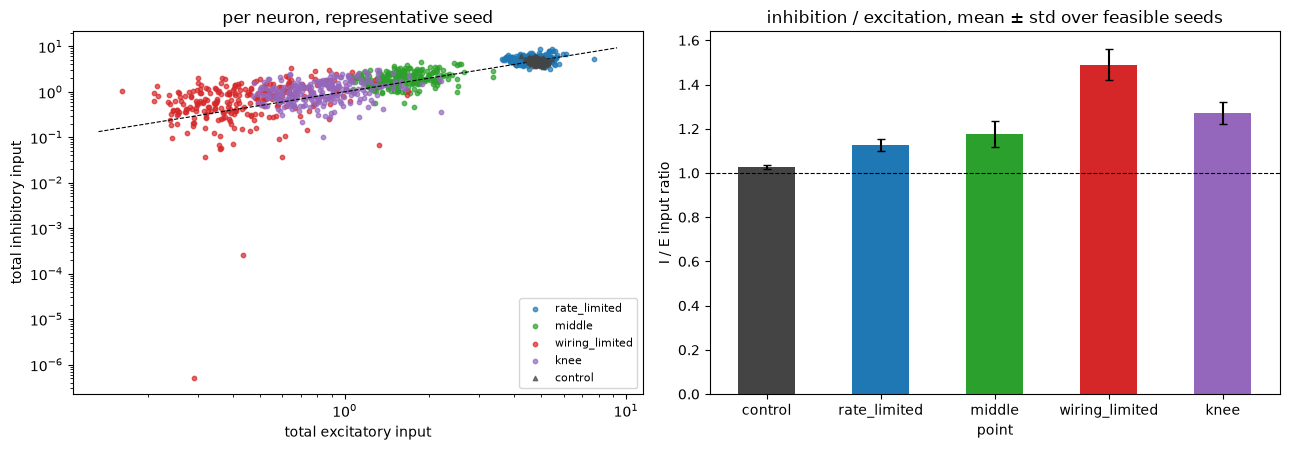

I/E (median over neurons)        corr(E in, I in)         \
                                    mean    std             mean    std   
point                                                                     
control                            1.028  0.010           -0.354  0.096   
rate_limited                       1.128  0.027            0.177  0.089   
middle                             1.176  0.061            0.396  0.053   
wiring_limited                     1.491  0.072            0.343  0.054   
knee                               1.271  0.050            0.382  0.071   

               rate-weighted I/E        rate-weighted corr        mean rate E  \
                            mean    std               mean    std        mean   
point                                                                           
control                    0.876  0.018             -0.227  0.091       0.798   
rate_limited               1.626  0.079              0.248  0.069       0.020   
middle                     1.874  0.144              0.390  0.055       0.036   
wiring_limited             2.649  0.234              0.301  0.080       0.089   
knee                       2.129  0.170              0.377  0.100       0.072   

                      mean rate I         
                  std        mean    std  
point                                     
control         0.162       0.680  0.139  
rate_limited    0.002       0.027  0.001  
middle          0.002       0.054  0.004  
wiring_limited  0.002       0.157  0.004  
knee            0.002       0.116  0.004

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ratio_rows = []
def ei_inputs(W, rate=None):
    # column sums of the E (positive) and I (negative) parts of W, optionally rate-weighted
    Wr = W if rate is None else W * rate[:, None]          # scale each presynaptic row by its rate
    return np.clip(Wr, 0, None).sum(axis=0), -np.clip(Wr, None, 0).sum(axis=0)

# control last so its points are drawn on top (they sit under rate_limited otherwise)
for p in POINTS[1:] + POINTS[:1]:
    _, ck, W = load(p, REP[p])
    exc, inh = ei_inputs(W)
    axes[0].scatter(exc, inh, s=10, color=COLORS[p], alpha=0.7, label=p,
                    marker="^" if p == "control" else "o", zorder=3 if p == "control" else 2)
for p in POINTS:
    for seed in sorted(zoom[(zoom.point == p) & zoom.is_feasible].seed):
        _, cks, Ws = load(p, seed)
        rate = cks["mean_rate"].mean(axis=0)                # (N,), averaged over tasks
        e, i = ei_inputs(Ws)
        er, ir = ei_inputs(Ws, rate)
        ratio_rows.append({"point": p, "seed": seed,
                           "I/E (median over neurons)": np.median(i / np.maximum(e, 1e-12)),
                           "corr(E in, I in)": np.corrcoef(e, i)[0, 1],
                           "rate-weighted I/E": np.median(ir / np.maximum(er, 1e-12)),
                           "rate-weighted corr": np.corrcoef(er, ir)[0, 1],
                           "mean rate E": rate[:N_E].mean(), "mean rate I": rate[N_E:].mean()})
axes[0].set_xscale("log"); axes[0].set_yscale("log")
lims = axes[0].get_xlim(); axes[0].plot(lims, lims, "k--", lw=0.8)
axes[0].set_xlabel("total excitatory input"); axes[0].set_ylabel("total inhibitory input")
axes[0].set_title("per neuron, representative seed"); axes[0].legend(fontsize=8)
bal = pd.DataFrame(ratio_rows)
summ = bal.groupby("point")[["I/E (median over neurons)", "corr(E in, I in)", "rate-weighted I/E",
                            "rate-weighted corr", "mean rate E", "mean rate I"]].agg(["mean", "std"]).reindex(POINTS)
summ["I/E (median over neurons)"]["mean"].plot.bar(yerr=summ["I/E (median over neurons)"]["std"], ax=axes[1],
                                                   color=[COLORS[p] for p in POINTS], capsize=3, rot=0)
axes[1].axhline(1, color="k", lw=0.8, ls="--"); axes[1].set_ylabel("I / E input ratio")
axes[1].set_title("inhibition / excitation, mean ± std over feasible seeds")
plt.tight_layout(); plt.show()
display(summ.round(3))

> **What we see (2.4).** This is the clearest result in the notebook so far.
>
> * **Ratio: constrained networks are inhibition-dominated.** In weights, I/E rises from 1.03 (control:
>   inhibition and excitation cancel almost exactly) through 1.13 (rate_limited), 1.18 (middle) and 1.27
>   (knee) to 1.49 (wiring_limited). The tighter the wiring budget, the more inhibition outweighs excitation.
> * **Correlation: balance becomes targeted.** In the control the correlation is **negative (-0.35)**:
>   inhibition is not matched to excitation at all. At every constrained point it is **positive (+0.18 to
>   +0.40)**: neurons that receive more excitation also receive more inhibition. **Detailed E/I balance
>   appears only when the network pays a cost**, and it is a hallmark of cortical circuits.
> * **Why it could help.** When each neuron's excitation is cancelled by its own inhibition, net inputs stay
>   small, so firing stays low (the metabolic budget) while the network can still respond quickly to
>   input changes. With few synapses (the wiring budget), stronger, targeted inhibition is a cheap way to
>   keep the remaining strong excitation in check.
> * **The currents make it stronger.** In every constrained network the inhibitory neurons fire more than
>   the excitatory ones (I/E rate 1.35x rate_limited, 1.5x middle, 1.6x knee, 1.8x wiring_limited), while in
>   the control E fires more (0.80 vs 0.68). So the rate-weighted ratio is **0.88 in the control**
>   (excitation slightly wins the actual currents) but **1.6-2.6 under the constraints** (rate_limited 1.63,
>   middle 1.87, knee 2.13, wiring_limited 2.65). The rate-weighted correlations keep the same signs
>   (control -0.23, constrained +0.25 to +0.39). Both views agree: the constrained networks are
>   inhibition-dominated and their inhibition is matched to excitation neuron by neuron; the control has
>   neither.
>
> **Caveats.** This is a structural measure (weights, and rates averaged over the whole trial), not a
> measurement of balance at each moment in time. And no null model yet: Dale's law plus differences in how
> many inputs each neuron has could create part of the correlation on their own. That test comes first in
> the next steps.

# Next steps (not implemented yet)

## A. Null model for the E/I balance result
The correlation between `E_j` and `I_j` could partly come from **structure that has nothing to do with
balance**. Example: if some neurons simply have more strong synapses of every kind (more inputs), they get
more excitation *and* more inhibition, so the correlation is positive without any targeted matching. Before
calling detailed balance a learned motif, compare the observed correlation with what shuffled networks
give, keeping exactly the properties we want to rule out:

1. **Shuffle targets within each presynaptic neuron.** Permute each row of `W` (a presynaptic neuron's
   outgoing synapses) across its targets. This keeps Dale's law (every row keeps its sign), every neuron's
   output strength and the weight distribution, but destroys *which* neuron receives *which* inhibition.
   If the observed correlation is far above this null distribution, inhibition is targeted.
2. **Also keep in-degree (degree-preserving swaps).** Swap pairs of synapses `(a→b, c→d) → (a→d, c→b)`
   within the same sign class. This keeps every neuron's number and strength of inputs as well. It is the
   stricter test: a correlation that survives it cannot be explained by "some neurons just get more input".

Report: observed correlation, null mean ± std (e.g. 1000 shuffles per network), and the z-score, per point
and seed. The same nulls also apply to the ratio.

## B. Cluster-to-cluster connectivity
Section 2.2 showed no block structure by eye. The quantitative question is: do neurons in the **same
functional cluster** (2.1) connect more strongly than neurons in different clusters, beyond chance?
Measure the mean connection strength within vs between clusters (a modularity score), separately for E→E,
E→I, I→E and I→I, and compare it with the same shuffled nulls as in A. Wiring costs are known to produce
modular networks in RNNs (Achterberg et al. 2023), so wiring_limited and knee are where to look first.